# Assignment 1: Probability Basics and Generative vs Discriminative Models

This notebook covers the foundational probability concepts from Lecture 1, including:
- Gaussian distributions (univariate and multivariate)
- Frequentist vs Bayesian interpretations
- The distinction between generative and discriminative models
- Sampling and visualisation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

---
## Part 1: Univariate Gaussian

The univariate Gaussian (Normal) distribution has PDF:

$$p(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

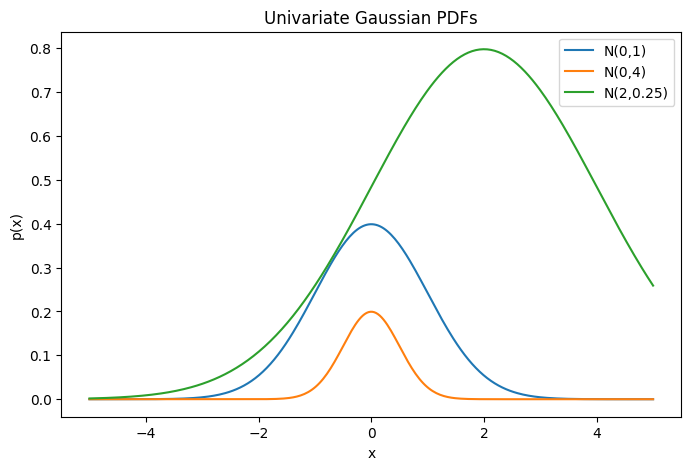

In [ ]:
def gaussian_pdf(x, mu, sigma):
    """
    Compute the univariate Gaussian PDF.

    Args:
        x     : float or np.ndarray, evaluation point(s)
        mu    : float, mean
        sigma : float, standard deviation (NOT variance)

    Returns:
        float or np.ndarray, PDF value(s)
    """
    # TODO: implement the univariate Gaussian PDF formula above
    # Hint: use np.exp and np.sqrt, not scipy
    raise NotImplementedError


# Test your implementation
x_test = np.linspace(-5, 5, 300)
for mu, sigma, label in [(0, 1, 'N(0,1)'), (0, 2, 'N(0,4)'), (2, 0.5, 'N(2,0.25)')]:
    plt.plot(x_test, gaussian_pdf(x_test, mu, sigma), label=label)

plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Univariate Gaussian PDFs')
plt.legend()
plt.show()

### 1.1 Sampling from a Gaussian

We can draw samples from a standard normal and then **transform** them:
$$x = \mu + \sigma \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$
This is the **reparameterisation trick** — you will use it again in the VAE notebook!

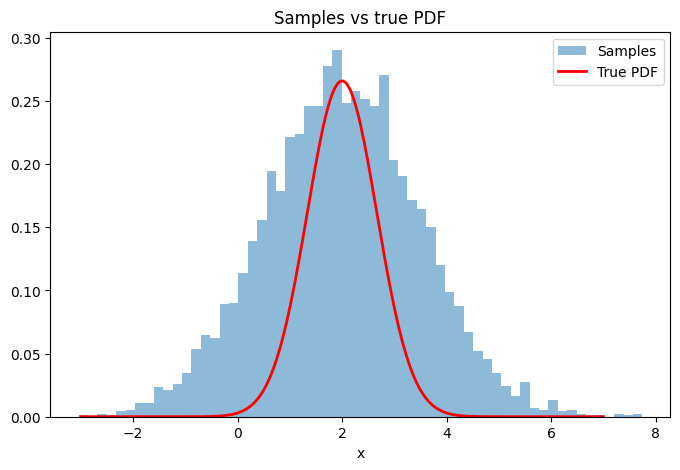

Sample mean:  2.003  (expected 2.0)
Sample std:   1.485  (expected 1.5)


In [ ]:
def sample_gaussian(mu, sigma, n_samples):
    """
    Draw samples from N(mu, sigma^2) using the reparameterisation trick.
    Do NOT use np.random.normal directly.

    Args:
        mu        : float, mean
        sigma     : float, standard deviation
        n_samples : int

    Returns:
        np.ndarray of shape (n_samples,)
    """
    # TODO:
    # 1. Draw epsilon ~ N(0,1) using np.random.randn
    # 2. Transform to N(mu, sigma^2)
    raise NotImplementedError


samples = sample_gaussian(mu=2.0, sigma=1.5, n_samples=5000)

x_plot = np.linspace(-3, 7, 300)
plt.hist(samples, bins=60, density=True, alpha=0.5, label='Samples')
plt.plot(x_plot, gaussian_pdf(x_plot, 2.0, 1.5), 'r-', lw=2, label='True PDF')
plt.xlabel('x')
plt.title('Samples vs true PDF')
plt.legend()
plt.show()

print(f'Sample mean:  {samples.mean():.3f}  (expected 2.0)')
print(f'Sample std:   {samples.std():.3f}  (expected 1.5)')

---
## Part 2: Multivariate Gaussian

The $D$-dimensional multivariate Gaussian has PDF:

$$p(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

The **covariance matrix** $\boldsymbol{\Sigma}$ encodes both variance along each axis and correlations between dimensions.

In [ ]:
def multivariate_gaussian_pdf(x, mu, Sigma):
    """
    Compute the multivariate Gaussian PDF for a single point.

    Args:
        x     : np.ndarray of shape (D,)
        mu    : np.ndarray of shape (D,)
        Sigma : np.ndarray of shape (D, D), covariance matrix

    Returns:
        float
    """
    D = len(mu)
    # TODO:
    # 1. Compute the determinant of Sigma  (np.linalg.det)
    # 2. Compute the inverse of Sigma      (np.linalg.inv)
    # 3. Compute the normalisation constant
    # 4. Compute the exponent:  -0.5 * (x-mu)^T Sigma^{-1} (x-mu)
    # 5. Return the product
    raise NotImplementedError


# Visualise the PDF for two covariance structures
grid_size = 100
x1 = np.linspace(-4, 4, grid_size)
x2 = np.linspace(-4, 4, grid_size)
X1, X2 = np.meshgrid(x1, x2)

mu = np.array([0.0, 0.0])
configs = [
    (np.array([[1, 0], [0, 1]]), 'Identity covariance (no correlation)'),
    (np.array([[2, 1], [1, 1]]), 'Correlated covariance'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (Sigma, title) in zip(axes, configs):
    Z = np.array([
        [multivariate_gaussian_pdf(np.array([x1v, x2v]), mu, Sigma)
         for x1v in x1] for x2v in x2
    ])
    ax.contourf(X1, X2, Z, levels=20, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
plt.tight_layout()
plt.show()

### 2.1 Understanding the covariance matrix

Experiment below with different covariance matrices and observe how the PDF shape changes.

In [ ]:
# TODO (exploration): Try at least three different covariance matrices:
#   (a) diagonal with different variances on each axis
#   (b) strong positive correlation (off-diagonal close to the product of stds)
#   (c) negative correlation
#
# For each, plot the contours of the PDF and describe in a comment what you observe.

# Example structure:
# Sigma_a = np.array([[3, 0], [0, 0.5]])
# ... plot ...

raise NotImplementedError

---
## Part 3: Frequentist vs Bayesian Interpretation

**Frequentist**: Parameters are fixed unknown constants; probability = long-run frequency.

**Bayesian**: Parameters are random variables; we maintain a *prior* belief $p(\theta)$, then update to a *posterior* $p(\theta | \mathcal{D})$ via Bayes' theorem:

$$p(\theta | \mathcal{D}) = \frac{p(\mathcal{D} | \theta) \, p(\theta)}{p(\mathcal{D})}$$

### Exercise: Bayesian coin flip

Suppose we flip a coin $N$ times and observe $h$ heads. The likelihood of $\theta$ (bias) given the data is:
$$p(h | \theta, N) = \binom{N}{h} \theta^h (1-\theta)^{N-h}$$

We use a **Beta prior**: $p(\theta) = \text{Beta}(\alpha, \beta)$ (conjugate to Binomial).
The posterior is then: $p(\theta | h) = \text{Beta}(\alpha + h, \, \beta + N - h)$.

In [ ]:
from scipy.stats import beta as beta_dist

def plot_bayesian_update(N_sequence, h_sequence, alpha_prior=1.0, beta_prior=1.0):
    """
    Visualise how the posterior over theta (coin bias) updates as we see more data.

    Args:
        N_sequence    : list of ints, cumulative number of flips at each step
        h_sequence    : list of ints, cumulative number of heads at each step
        alpha_prior   : float, Beta prior parameter alpha
        beta_prior    : float, Beta prior parameter beta
    """
    theta_grid = np.linspace(0, 1, 300)
    plt.figure(figsize=(10, 5))

    # Plot prior
    plt.plot(theta_grid, beta_dist.pdf(theta_grid, alpha_prior, beta_prior),
             '--', label=f'Prior Beta({alpha_prior},{beta_prior})')

    for N, h in zip(N_sequence, h_sequence):
        # TODO: compute posterior Beta parameters after seeing h heads in N flips
        alpha_post = None  # TODO
        beta_post  = None  # TODO

        posterior = beta_dist.pdf(theta_grid, alpha_post, beta_post)
        plt.plot(theta_grid, posterior, label=f'N={N}, h={h}')

    plt.axvline(0.7, color='black', linestyle=':', label='True theta=0.7')
    plt.xlabel('theta (bias)')
    plt.ylabel('Posterior density')
    plt.title('Bayesian updating of coin-flip posterior')
    plt.legend()
    plt.show()


# Simulate flipping a biased coin (true theta = 0.7)
true_theta = 0.7
flips = np.random.binomial(1, true_theta, size=200)
N_steps = [5, 20, 50, 200]
h_steps = [flips[:n].sum() for n in N_steps]

plot_bayesian_update(N_steps, h_steps)

**Reflection question** (answer in the cell below):
1. What happens to the posterior as $N \to \infty$?
2. With a flat (uniform) prior Beta(1,1), is the posterior mode equal to the MLE estimate $h/N$? Why?
3. How does a strong prior Beta(10,10) (believing the coin is fair) affect learning when the true bias is 0.7?

**Your answers:**

1. TODO
2. TODO
3. TODO

In [ ]:
# TODO (exploration): Run plot_bayesian_update with a strong prior Beta(10,10)
# and compare to the flat prior Beta(1,1). How many observations are needed
# to overcome the prior?

raise NotImplementedError

---
## Part 4: Generative vs Discriminative Models

**Discriminative model**: learns $p(y | x)$ — the conditional probability of the label given the input.

**Generative model**: learns the **joint** distribution $p(x, y) = p(x | y)\, p(y)$.
From the joint we can always recover the conditional: $p(y|x) = p(x,y)/p(x)$.

### Naive Bayes classifier as a generative model

A Gaussian Naive Bayes classifier models:
- Class prior: $p(y = k) = \pi_k$
- Class-conditional: $p(x | y = k) = \mathcal{N}(x | \mu_k, \sigma_k^2)$ (each feature independent)

Prediction: $p(y=k|x) \propto p(x|y=k)\,p(y=k)$

In [ ]:
# Generate 2-class 1D data
np.random.seed(0)
n0, n1 = 200, 300
X0 = np.random.normal(-1.5, 1.0, n0)
X1 = np.random.normal(2.0, 1.5, n1)
X = np.concatenate([X0, X1])
y = np.concatenate([np.zeros(n0), np.ones(n1)])


class GaussianNaiveBayes1D:
    """Generative 1D binary classifier."""

    def fit(self, X, y):
        """
        Estimate parameters from data via MLE.

        After calling fit, the model should have:
            self.pi   : list of class priors [pi_0, pi_1]
            self.mu   : list of class means  [mu_0, mu_1]
            self.sigma: list of class stds   [sigma_0, sigma_1]
        """
        classes = [0, 1]
        N = len(X)
        self.pi = []
        self.mu = []
        self.sigma = []

        for c in classes:
            Xc = X[y == c]
            # TODO: compute pi_c, mu_c, sigma_c from Xc
            # (MLE estimates: empirical mean and std)
            pi_c    = None  # TODO
            mu_c    = None  # TODO
            sigma_c = None  # TODO

            self.pi.append(pi_c)
            self.mu.append(mu_c)
            self.sigma.append(sigma_c)

    def predict_proba(self, x):
        """
        Return P(y=1 | x) using Bayes' theorem.

        Args:
            x : float or np.ndarray

        Returns:
            float or np.ndarray, posterior probability of class 1
        """
        # TODO:
        # 1. Compute p(x | y=k) for k=0,1 using your gaussian_pdf function
        # 2. Compute unnormalised posteriors: p(x|y=k) * pi_k
        # 3. Normalise so they sum to 1, return the class-1 probability
        raise NotImplementedError

    def predict(self, x, threshold=0.5):
        return (self.predict_proba(x) >= threshold).astype(int)


gnb = GaussianNaiveBayes1D()
gnb.fit(X, y)

x_plot = np.linspace(-6, 7, 400)
plt.figure(figsize=(10, 5))
plt.hist(X0, bins=30, density=True, alpha=0.4, color='blue', label='Class 0 data')
plt.hist(X1, bins=30, density=True, alpha=0.4, color='orange', label='Class 1 data')
plt.plot(x_plot, gaussian_pdf(x_plot, gnb.mu[0], gnb.sigma[0]) * gnb.pi[0],
         'b-', lw=2, label='p(x,y=0) fitted')
plt.plot(x_plot, gaussian_pdf(x_plot, gnb.mu[1], gnb.sigma[1]) * gnb.pi[1],
         'r-', lw=2, label='p(x,y=1) fitted')
plt.plot(x_plot, gnb.predict_proba(x_plot), 'k--', lw=1.5, label='P(y=1|x)')
plt.xlabel('x')
plt.title('Gaussian Naive Bayes: joint and posterior')
plt.legend()
plt.show()

y_pred = gnb.predict(X)
accuracy = (y_pred == y).mean()
print(f'Training accuracy: {accuracy:.3f}')

### 4.1 Generating new samples

One key advantage of generative models: we can **sample** from $p(x)$ or $p(x|y)$.

In [ ]:
def generate_samples(gnb, n_samples):
    """
    Draw samples from the fitted generative model p(x, y).

    Steps:
        1. Sample class label y ~ Categorical(pi_0, pi_1)
        2. Given y, sample x ~ N(mu_y, sigma_y^2)

    Returns:
        X_gen : np.ndarray of shape (n_samples,)
        y_gen : np.ndarray of shape (n_samples,)
    """
    # TODO
    # Hint for step 1: np.random.choice([0, 1], p=[pi_0, pi_1], size=n_samples)
    raise NotImplementedError


X_gen, y_gen = generate_samples(gnb, 1000)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(X[y==0], bins=30, density=True, alpha=0.5, label='Real class 0')
plt.hist(X_gen[y_gen==0], bins=30, density=True, alpha=0.5, label='Generated class 0')
plt.title('Class 0')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(X[y==1], bins=30, density=True, alpha=0.5, label='Real class 1')
plt.hist(X_gen[y_gen==1], bins=30, density=True, alpha=0.5, label='Generated class 1')
plt.title('Class 1')
plt.legend()

plt.tight_layout()
plt.show()

---
## Part 5: Families of Generative Models (Conceptual)

The course covers five families of generative models. Fill in the table below based on your understanding from the lecture. No code required here — this is a conceptual review.

| Family | Core idea | Pros | Cons |
|--------|-----------|------|------|
| Autoregressive | TODO | TODO | TODO |
| VAE | TODO | TODO | TODO |
| Flow-based | TODO | TODO | TODO |
| Diffusion | TODO | TODO | TODO |
| GAN | TODO | TODO | TODO |

---
## Summary

In this notebook you:
- Implemented the univariate and multivariate Gaussian PDFs from scratch
- Used the reparameterisation trick to draw samples
- Visualised Bayesian updating with a conjugate Beta–Binomial model
- Built a generative classifier (Gaussian Naive Bayes) and used it to both classify and generate data

**Next**: Assignment 2 covers KL divergence and Maximum Likelihood Estimation.